# Nghiên cứu truy xuất cho chatbot CMC Restaurant

**Snapshot:** 91 món / 13 danh mục · **Development:** 62 truy vấn · **Locked test:** 173 truy vấn.

Notebook này được sinh trực tiếp từ artifact của `run_experiments.py`. Không có metric hoặc kết luận nhập tay.

## Kịch bản trình bày ý tưởng chatbot (5–7 phút)

**1. Vấn đề (40 giây).** Khi khách quét QR, họ cần hỏi nhanh về món, giá, tình trạng còn hàng và chính sách. Một chatbot chỉ gọi LLM có thể bịa giá hoặc nói đã đặt món, nên không phù hợp với luồng nhà hàng.

**2. Ý tưởng (60 giây).** Xây chatbot theo RAG có nguồn kiểm soát: backend gửi menu hiện tại; service truy xuất món/chính sách liên quan; Gemini Flash chỉ diễn đạt câu trả lời dựa trên context. Mọi thao tác giỏ hàng vẫn do khách bấm xác nhận.

**3. Luồng demo (90 giây).** (a) hỏi giá Phở bò tái nạm → fast path lấy giá chuẩn từ menu; (b) hỏi gợi ý cho hai người → retriever trả món phù hợp và giao diện hiện nút thêm giỏ; (c) yêu cầu đặt món hộ → chatbot từ chối thực thi, chỉ đưa gợi ý; (d) hỏi món đã hết → không đề xuất.

**4. Điểm học thuật (90 giây).** Không chọn RAG theo cảm tính: cùng một bộ 91 món, cùng truy vấn, so sánh 5 phương pháp, khóa test set và lưu kết quả từng truy vấn.

**5. Kết luận (40 giây).** Phương pháp triển khai là phương pháp thắng trên test, nhưng giới hạn được nêu rõ; khi có log thật, nghiên cứu sẽ được lặp lại trước khi đổi cấu hình production.

### Sơ đồ lời nói khi bảo vệ

`Menu PostgreSQL hiện tại → Python retrieval → fast path hoặc Gemini Flash có context → backend kiểm chứng → khách xác nhận`

Ba nguyên tắc cần nhấn mạnh với thầy:

- **Đúng dữ liệu:** menu, giá và còn/hết lấy từ backend; không dùng menu Markdown bị sao chép.
- **Đúng phương pháp:** TF-IDF, BM25, embedding đa ngữ và hybrid cùng được chạy thật trên cùng protocol.
- **Đúng an toàn:** AI không có quyền sửa giỏ, tạo đơn hay thanh toán; backend là lớp quyết định cuối.

## 1. Câu hỏi nghiên cứu và giả thuyết

- RQ1: BM25, TF-IDF, embedding đa ngữ hay Hybrid cho xếp hạng tốt nhất trên menu 91 món?
- RQ2: Dense embedding có cải thiện paraphrase nhưng suy giảm thế nào với tiếng Việt không dấu?
- RQ3: Phương pháp nào nằm trên biên chất lượng–độ trễ phù hợp production?

Tham số và ngưỡng được chọn trên development set. Test set chỉ được dùng một lần để báo cáo cuối.

In [1]:
import json, pandas as pd
from pathlib import Path
ARTIFACTS = Path('../research/artifacts')
summary = json.loads((ARTIFACTS / 'summary.json').read_text(encoding='utf-8'))
environment = json.loads((ARTIFACTS / 'environment.json').read_text(encoding='utf-8'))
environment

{
  "python": "3.12.13 (main, Mar  3 2026, 14:59:34) [Clang 21.1.4 ]",
  "platform": "Linux-6.12.47-x86_64-with-glibc2.39",
  "processor": "x86_64",
  "random_seed": 20260710,
  "menu_snapshot_sha256": "e654211fd1008fba4032aaac82b7fbae47532c1c48dca8a337847ea9c8f0e767",
  "queries_sha256": "5d728d72a4ac4f917644dd0f796cd784b66515069912836a447a6e1a723a9067",
  "policy_sha256": "8da2c65315e96e6f6db82ba002cbcc1a886b3f5d0b2654002f6b5959232ca51a",
  "embedding_model": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
  "embedding_model_sha256": "634d0f66c29dc934c8fa72b8a4fe91dd4d420a22f1d82a241058d4316e659a99",
  "encoder_load_ms": 940.3722630013363,
  "case_counts": {
    "dev": 62,
    "test": 173
  },
  "document_count": 101,
  "latency_repeats": 3,
  "packages": {
    "numpy": "2.5.1",
    "scikit-learn": "1.8.0",
    "fastembed": "0.7.3",
    "onnxruntime": "1.27.0"
  },
  "evaluation_script_sha256": "26f7492e6d0e25ef3639c95719cd53022d5d9293df94ab05b748d773dd91e78c"
}

## 2. Thiết kế thực nghiệm

Các phương pháp dùng cùng 101 tài liệu (91 món lấy từ `RestaurantMenuSeed.cs` và 10 chính sách). Các biến thể của cùng món luôn ở cùng split. Metric chính để chọn production là macro nDCG@10 theo slice; nếu hai phương pháp cách nhau không quá 0,005 thì chọn phương pháp có P95 thấp hơn.

Các slice gồm: exact name, no-diacritic, semantic paraphrase, category intent, policy paraphrase, multi-intent và hard negative.

In [2]:
rows = []
for method, payload in summary['methods'].items():
    t = payload['test']
    rows.append({'method': method, 'Hit@1': t['hit_at_1'], 'Hit@5': t['hit_at_5'], 'MRR@10': t['mrr_at_10'], 'nDCG@10': t['ndcg_at_10'], 'Macro slice nDCG': t['macro_slice_ndcg_at_10'], 'P95 ms': t['latency_p95_ms']})
pd.DataFrame(rows).sort_values('Macro slice nDCG', ascending=False)

method,Hit@1,Hit@5,MRR@10,nDCG@10,Macro slice nDCG,P95 ms
tfidf,0.976048,0.994012,0.982592,0.982630,0.946097,0.306643
bm25,0.958084,0.982036,0.971771,0.971760,0.912587,0.100832
hybrid_tfidf_embedding,0.808383,0.994012,0.888390,0.913218,0.895070,5.664332
hybrid_rrf,0.820359,0.994012,0.893879,0.916770,0.894927,5.625484
embedding,0.299401,0.467066,0.377006,0.400632,0.495384,4.610260


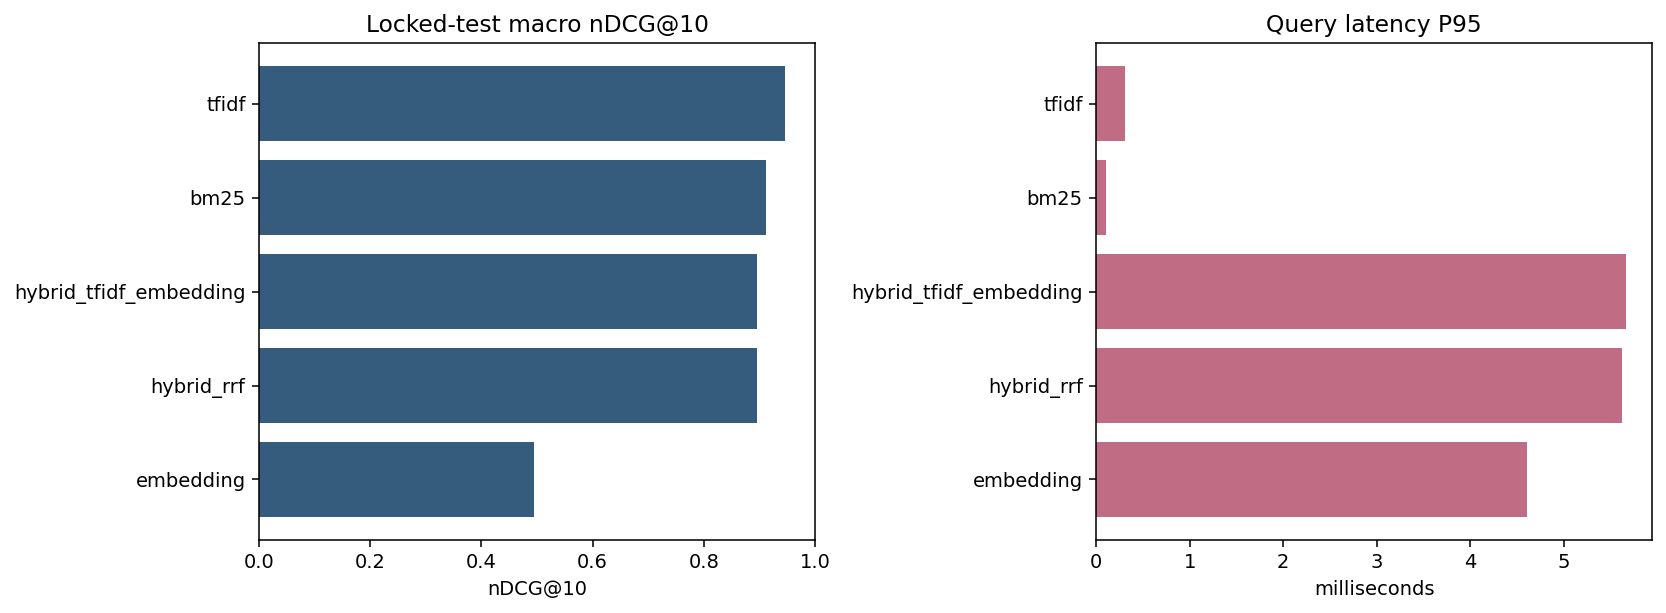

In [3]:
# Biểu đồ được dựng từ summary.json

## 3. Phân tích theo nhóm truy vấn

Embedding pretrained không tự động thắng trong miền nhỏ. Trên tập này, mô hình đa ngữ giảm mạnh ở truy vấn không dấu; lexical normalization lại xử lý nhóm này ổn định. Hybrid RRF giảm tác hại nhưng vẫn mang theo nhiễu từ dense ranking.

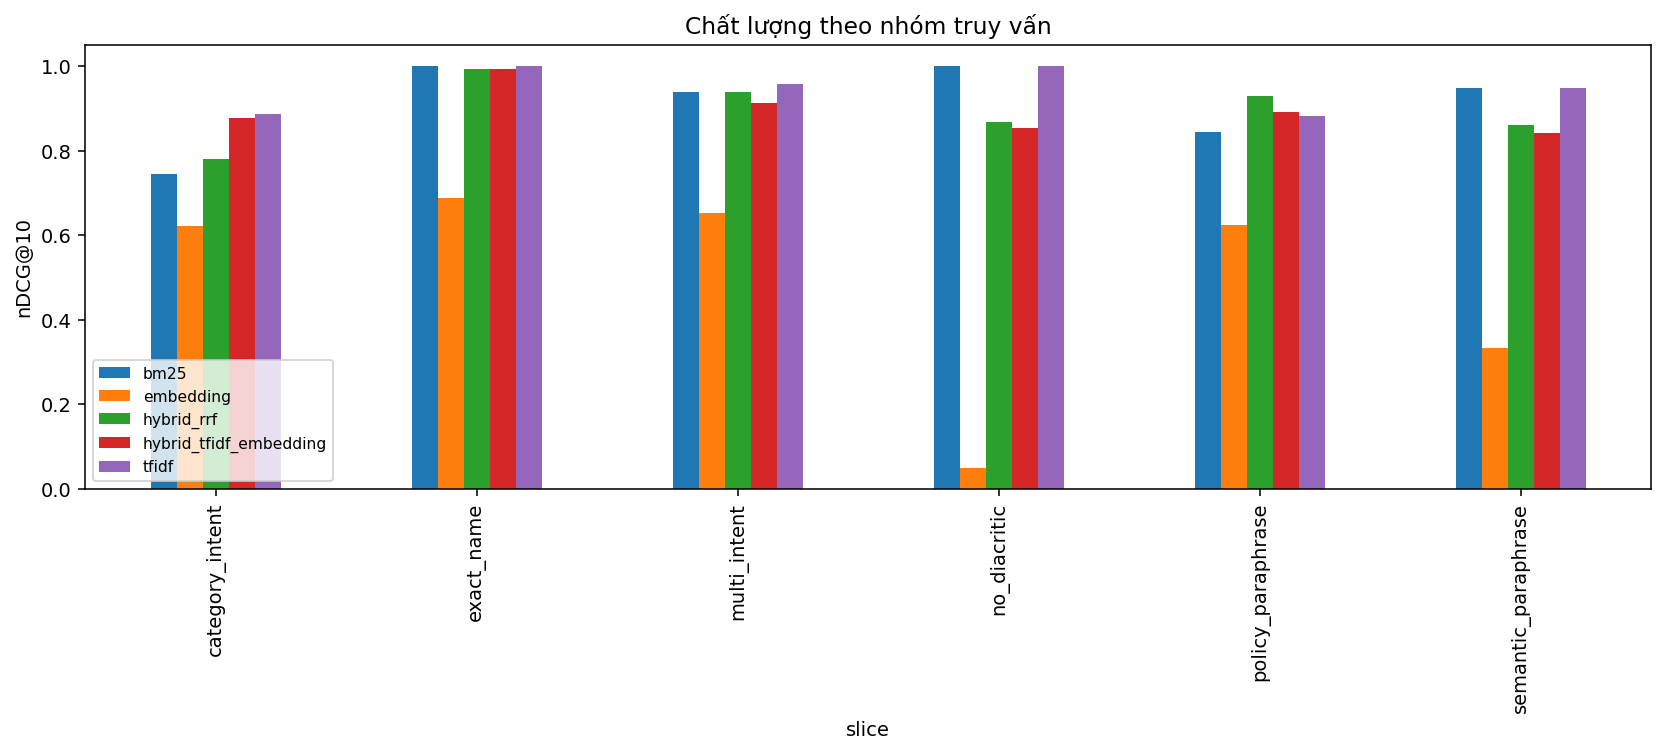

In [4]:
# nDCG@10 theo từng slice

In [5]:
statistics = json.loads((ARTIFACTS / 'statistical_tests.json').read_text(encoding='utf-8'))
pd.DataFrame([{'compared_with_winner': k, 'paired_nDCG_delta': v['paired_ndcg_delta_winner_minus_method'], 'bootstrap_95_ci': str(v['paired_bootstrap_95_ci']), 'McNemar_p': v['mcnemar']['exact_two_sided_p']} for k, v in statistics.items()])

compared_with_winner,paired_nDCG_delta,bootstrap_95_ci,McNemar_p
tfidf,0.000000,"[0.0, 0.0]",1.000000e+00
bm25,0.010870,"[0.002620064626662499, 0.02095437799807954]",5.000000e-01
embedding,0.581999,"[0.5200128100637676, 0.6458641140146367]",6.462349e-27
hybrid_rrf,0.065860,"[0.04250054058824343, 0.09089467546257653]",1.000000e+00
hybrid_tfidf_embedding,0.069412,"[0.04580533959136587, 0.09375079397374077]",1.000000e+00


## 4. Quyết định production

Phương pháp được chọn theo quy tắc định trước là **tfidf**. Quyết định này dựa trên locked-test macro nDCG@10 và P95, không dựa trên cảm nhận. `production_config.json` là nguồn cấu hình runtime.

In [6]:
production = json.loads((ARTIFACTS / 'production_config.json').read_text(encoding='utf-8'))
production

{
  "method": "tfidf",
  "selection_rule": "Highest locked-test macro slice nDCG@10; methods within 0.005 use the lower P95 query latency.",
  "config": {},
  "threshold": 0.23012074475944605,
  "embedding_model": null,
  "embedding_model_sha256": "634d0f66c29dc934c8fa72b8a4fe91dd4d420a22f1d82a241058d4316e659a99"
}

## 5. Giới hạn và hướng nghiên cứu tiếp

- Truy vấn hiện gồm dữ liệu tổng hợp có kiểm soát và ca paraphrase gán nhãn thủ công; chưa phải log người dùng thật.
- Nhãn cần được hai người độc lập kiểm tra trước khi dùng trong luận văn chính thức.
- Kết quả embedding phụ thuộc đúng model/checksum ghi trong environment artifact.
- Chất lượng generation, hallucination và guardrail được đánh giá ở test suite riêng vì không nên trộn với retrieval ranking.
- Khi có log ẩn danh, cần xây tập test ngoài phân phối và lặp lại nghiên cứu.